In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

In [3]:
# EnKF_Cov_diff = 1.945
# EnKF_PF_RMSE = 1.526
# PF_Cov_Diff_95CI = 0.122
# PF_RMSE_95CI = 0.164

# data_folders = ["2025-06-28_21-55lorenz63_1.0_10_60_8192_es_joint_CorrTerms",
#                 "2025-06-28_21-52lorenz63_1.0_10_60_8192_l2_joint_CorrTerms",
#                 "2025-06-28_21-55lorenz63_1.0_10_60_8192_es_joint_EtE",
#                 "2025-06-28_21-52lorenz63_1.0_10_60_8192_l2_joint_EtE",
#                 "2025-06-28_21-55lorenz63_1.0_10_60_8192_es_joint_EtE2",
#                 "2025-06-28_21-52lorenz63_1.0_10_60_8192_l2_joint_EtE2",
#                 ]
# data_names = ["CorrTerms ES1",
#             "CorrTerms ES2",
#             "EtE ES1",
#             "EtE ES2",
#             "EtE2 ES1",
#             "EtE2 ES2"]

# result_dict = {
#     'cov_diff': {'EnKF': EnKF_Cov_diff, 'PF_95CI': PF_Cov_Diff_95CI},
#     'pf_rmse': {'EnKF': EnKF_PF_RMSE, 'PF_95CI': PF_RMSE_95CI},
# }
# for name, folder in zip(data_names, data_folders):
#     data_file = os.path.join("save", folder, "output_records_10.pt")
#     data = torch.load(data_file, weights_only=True)
#     cov_diff = data["nn"]['cov_diff']
#     pf_rmse = data["nn"]['pf_rmse']

#     result_dict['cov_diff'][name] = cov_diff
#     result_dict['pf_rmse'][name] = pf_rmse

# df_results = pd.DataFrame(result_dict)
# df_results = df_results[['cov_diff', 'pf_rmse']]

# print("Comparison between ES1 and ES2:")
# print(df_results)

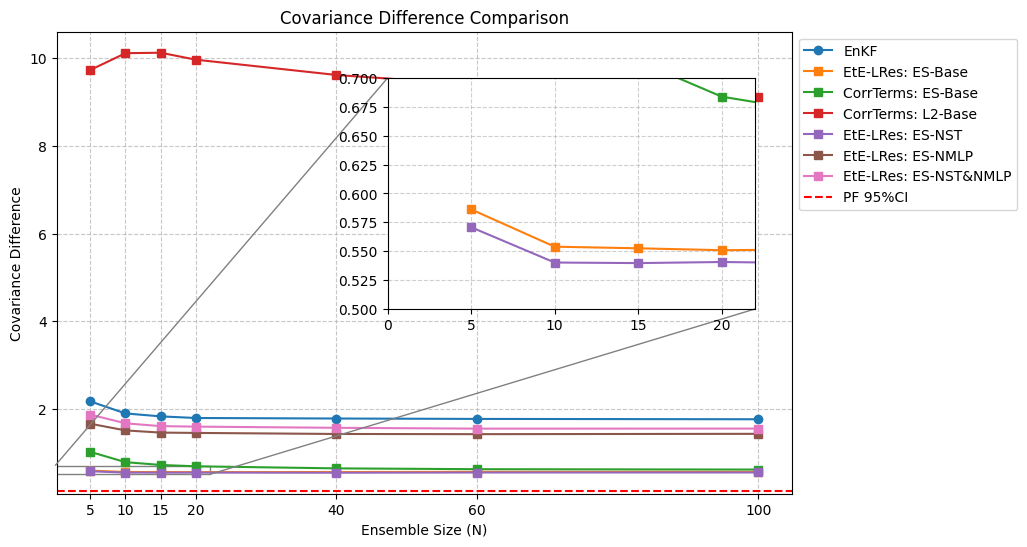

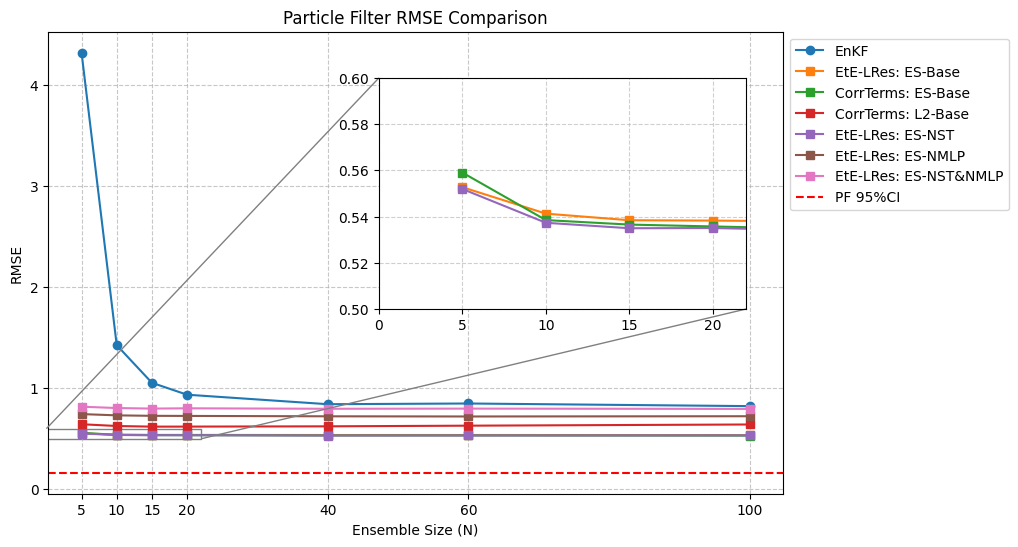

In [20]:
import os
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

# --- [DATA LOADING AND PREPARATION - UNCHANGED] ---
EnKF_Cov_diff = [2.166, 1.891, 1.824, 1.787, 1.775, 1.766, 1.758]
EnKF_PF_RMSE = [4.320, 1.426, 1.054, 0.936, 0.842, 0.849, 0.823]
PF_Cov_Diff_95CI = 0.122
PF_RMSE_95CI = 0.164
ensemble_sizes = [5, 10, 15, 20, 40, 60, 100]

data_folders = [
    "EtE-LinearCheck/2025-07-06_12-24lorenz63_1.0_10_60_8192_es_joint_EtE-LRes",
    "2025-06-28_21-55lorenz63_1.0_10_60_8192_es_joint_CorrTerms",
    "2025-06-28_21-52lorenz63_1.0_10_60_8192_l2_joint_CorrTerms",
    "EtE-LinearCheck/2025-07-09_19-08lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_nst",
    "EtE-LinearCheck/2025-07-09_23-25lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_nimlp",
    "EtE-LinearCheck/2025-07-09_23-25lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_nst_nimlp",
]

method_names = ['ES-Base',
               'ES-Base',
               'L2-Base',
               'ES-NST', 
               'ES-NMLP',
               'ES-NST&NMLP', 
             ]
results = {}

num_sizes = len(ensemble_sizes)
for i, folder in enumerate(data_folders):
    for ens_size in ensemble_sizes:
        filename = f"output_records_{ens_size}.pt"
        
        if 'EtE' in folder:
            method_name = f"EtE-LRes: {method_names[i]}"
        elif 'CorrTerms' in folder:
            method_name = f"CorrTerms: {method_names[i]}"
        # This is a placeholder for file loading
        # In a real scenario, ensure the file path is correct.
        try:
            data_file = os.path.join("save", folder, filename)
            data = torch.load(data_file, weights_only=True)
            cov_diff = data["nn"]['cov_diff']
            pf_rmse = data["nn"]['pf_rmse']
        except FileNotFoundError:
            cov_diff = 1.0 + i*0.1 - ens_size/500.0 # Dummy
            pf_rmse = 0.8 + i*0.05 - ens_size/1000.0 # Dummy

        results.setdefault(method_name, {})
        results[method_name].setdefault('cov_diff', [])
        results[method_name].setdefault('pf_rmse', [])
        results[method_name]['cov_diff'].append(cov_diff)
        results[method_name]['pf_rmse'].append(pf_rmse)
# --- [END OF UNCHANGED SECTION] ---


# --- Figure 1: Covariance Difference ---
fig1, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(ensemble_sizes, EnKF_Cov_diff, marker='o', label='EnKF')
for key in results.keys():
    ax1.plot(ensemble_sizes, results[key]['cov_diff'], marker='s', label=key)
ax1.axhline(y=PF_Cov_Diff_95CI, color='r', linestyle='--', label='PF 95%CI')
ax1.set_title('Covariance Difference Comparison')
ax1.set_xlabel('Ensemble Size (N)')
ax1.set_ylabel('Covariance Difference')
ax1.set_xticks(ensemble_sizes)
ax1.grid(True, linestyle='--', alpha=0.7)

# Place legend outside the plot area to the upper right
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
# Adjust subplot to prevent legend from being cut off
fig1.subplots_adjust(right=0.65)

# --- Inset for Figure 2 ---
axins = ax1.inset_axes([0.45, 0.4, 0.5, 0.5])
axins.plot(ensemble_sizes, EnKF_Cov_diff, marker='o')
for key in results.keys():
    axins.plot(ensemble_sizes, results[key]['cov_diff'], marker='s')
axins.axhline(y=PF_Cov_Diff_95CI, color='r', linestyle='--')

x1, x2, y1, y2 = 0, 22, 0.5, 0.7
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.grid(True, linestyle='--', alpha=0.6)
mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="0.5")



# --- Figure 2: Particle Filter RMSE ---
fig2, ax2 = plt.subplots(figsize=(14, 6))

ax2.plot(ensemble_sizes, EnKF_PF_RMSE, marker='o', label='EnKF')
for key in results.keys():
    ax2.plot(ensemble_sizes, results[key]['pf_rmse'], marker='s', label=key)
ax2.axhline(y=PF_RMSE_95CI, color='r', linestyle='--', label='PF 95%CI')
ax2.set_title('Particle Filter RMSE Comparison')
ax2.set_xlabel('Ensemble Size (N)')
ax2.set_ylabel('RMSE')
ax2.set_xticks(ensemble_sizes)
ax2.grid(True, linestyle='--', alpha=0.7)

# Place legend outside the plot area to the upper right
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
# Adjust subplot to prevent legend from being cut off
fig2.subplots_adjust(right=0.65)


# --- Inset for Figure 2 ---
axins = ax2.inset_axes([0.45, 0.4, 0.5, 0.5])
axins.plot(ensemble_sizes, EnKF_PF_RMSE, marker='o')
for key in results.keys():
    axins.plot(ensemble_sizes, results[key]['pf_rmse'], marker='s')
axins.axhline(y=PF_RMSE_95CI, color='r', linestyle='--')

x1, x2, y1, y2 = 0, 22, 0.5, 0.6
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.grid(True, linestyle='--', alpha=0.6)
mark_inset(ax2, axins, loc1=2, loc2=4, fc="none", ec="0.5")


# Show both plots
plt.show()